# 🪨 Random Forest vs KNN — Lithology Prediction
## Multi-Well Study: F02-01 | F03-02 | F03-04 | F06-01

This notebook compares **Random Forest** and **K-Nearest Neighbors (KNN)** for lithology  
prediction using real well log data from 4 North Sea wells.

---
### Study Design
| Stage | Approach |
|-------|----------|
| **Training** | 3 wells (F02-01, F03-02, F03-04) — learn log-to-lithology relationships |
| **Blind Test** | 1 well (F06-01) — predict lithology never seen during training |
| **Features** | GR · RHOB · DT (corrected) · PHIE (porosity) |
| **Labels** | Rule-based petrophysical cut-offs (no core data available) |

### Why This Matters in Geoscience
Training on multiple wells and testing on a blind well is the **industry-standard validation**  
for machine learning in subsurface work — it tests whether a model truly generalises  
across different borehole environments, not just within a single well.

---
## Step 1: Install & Import Libraries

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lasio', '-q'], check=True)

import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import AutoMinorLocator

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('✅ All libraries loaded.')

✅ All libraries loaded.


---
## Step 2: Load All 4 Wells

In [3]:
# ── Configuration — update paths if needed ────────────────
WELL_FILES = {
    'F02-01': 'F02-01_logs.las',
    'F03-02': 'F03-02_logs.las',
    'F03-04': 'F03-04_logs.las',
    'F06-01': 'F06-01_logs.las',   # ← blind test well
}
FEATURES   = ['GR', 'RHOB', 'DT_CORR', 'PHIE']
WELL_COLORS = {
    'F02-01': '#E74C3C',
    'F03-02': '#2ECC71',
    'F03-04': '#3498DB',
    'F06-01': '#F39C12',
}

def load_well(path, well_name):
    """Load a LAS file and return a clean DataFrame."""
    las = lasio.read(path)
    df  = las.df().replace(-999.25, np.nan).copy()
    df.index.name = 'DEPTH'
    df.rename(columns={'DT:1':'DT_RAW','DT:2':'DT_CORR','UNKNOWN':'PHIE'}, inplace=True)
    # Keep only the 4 shared features
    df = df[['GR','RHOB','DT_CORR','PHIE']].copy()
    df['WELL'] = well_name
    return df

# Load all wells
well_dfs = {}
for wname, wpath in WELL_FILES.items():
    well_dfs[wname] = load_well(wpath, wname)
    df = well_dfs[wname]
    complete = df[FEATURES].dropna()
    print(f'{wname}  |  depth: {df.index.min():.0f}–{df.index.max():.0f} m  '
          f'|  {len(complete):,} complete rows  |  GR: {complete["GR"].mean():.1f} API')

print('\n✅ All wells loaded successfully.')

F02-01  |  depth: 30–3150 m  |  4,418 complete rows  |  GR: 59.0 API
F03-02  |  depth: 30–2140 m  |  13,771 complete rows  |  GR: 39.8 API
F03-04  |  depth: 30–1900 m  |  11,789 complete rows  |  GR: 46.7 API
F06-01  |  depth: 29–1700 m  |  10,826 complete rows  |  GR: 47.4 API

✅ All wells loaded successfully.


---
## Step 3: Rule-Based Lithology Labelling

No core data is available, so we apply **petrophysical cut-offs** consistently across all wells.

| Lithology | GR (API) | RHOB (g/cc) | PHIE (frac) | Label |
|-----------|----------|-------------|-------------|-------|
| Shale | ≥ 70 | — | — | 0 |
| Sandstone | < 70 | < 2.20 | ≥ 0.25 | 1 |
| Tight Sand | < 70 | 2.20–2.60 | < 0.25 | 2 |
| Carbonate | < 35 | ≥ 2.60 | — | 3 |

In [5]:
LITH_NAMES  = {0:'Shale', 1:'Sandstone', 2:'Tight Sand', 3:'Carbonate'}
LITH_COLORS = {0:'#8B6914', 1:'#F5DEB3', 2:'#DAA520',   3:'#87CEEB'}

def label_lithology(row):
    gr, rhob, phie = row['GR'], row['RHOB'], row['PHIE']
    if pd.isna(gr) or pd.isna(rhob):
        return np.nan
    if gr >= 70:
        return 0  # Shale
    elif gr < 35 and rhob >= 2.60:
        return 3  # Carbonate
    elif rhob < 2.20 and pd.notna(phie) and phie >= 0.25:
        return 1  # Sandstone
    else:
        return 2  # Tight Sand

for wname, df in well_dfs.items():
    df['LITH']      = df.apply(label_lithology, axis=1)
    df['LITH_NAME'] = df['LITH'].map(LITH_NAMES)

# Summary table
print('Lithology distribution per well (%):\n')
header = f'{"":<12}' + ''.join(f'{n:>13}' for n in LITH_NAMES.values())
print(header)
print('─' * (12 + 13 * 4))
for wname, df in well_dfs.items():
    vc    = df['LITH'].value_counts(normalize=True).sort_index() * 100
    row_s = f'{wname:<12}'
    for lid in LITH_NAMES:
        row_s += f'{vc.get(lid, 0):>12.1f}%'
    print(row_s)

Lithology distribution per well (%):

                    Shale    Sandstone   Tight Sand    Carbonate
────────────────────────────────────────────────────────────────
F02-01              18.7%        18.0%        63.3%         0.0%
F03-02              10.8%        70.6%        18.0%         0.5%
F03-04              14.0%        75.3%        10.7%         0.0%
F06-01              13.7%        70.0%        16.3%         0.0%


---
## Step 4: Multi-Well Log Overview

Plot all 4 wells side by side — GR and RHOB coloured by lithology.

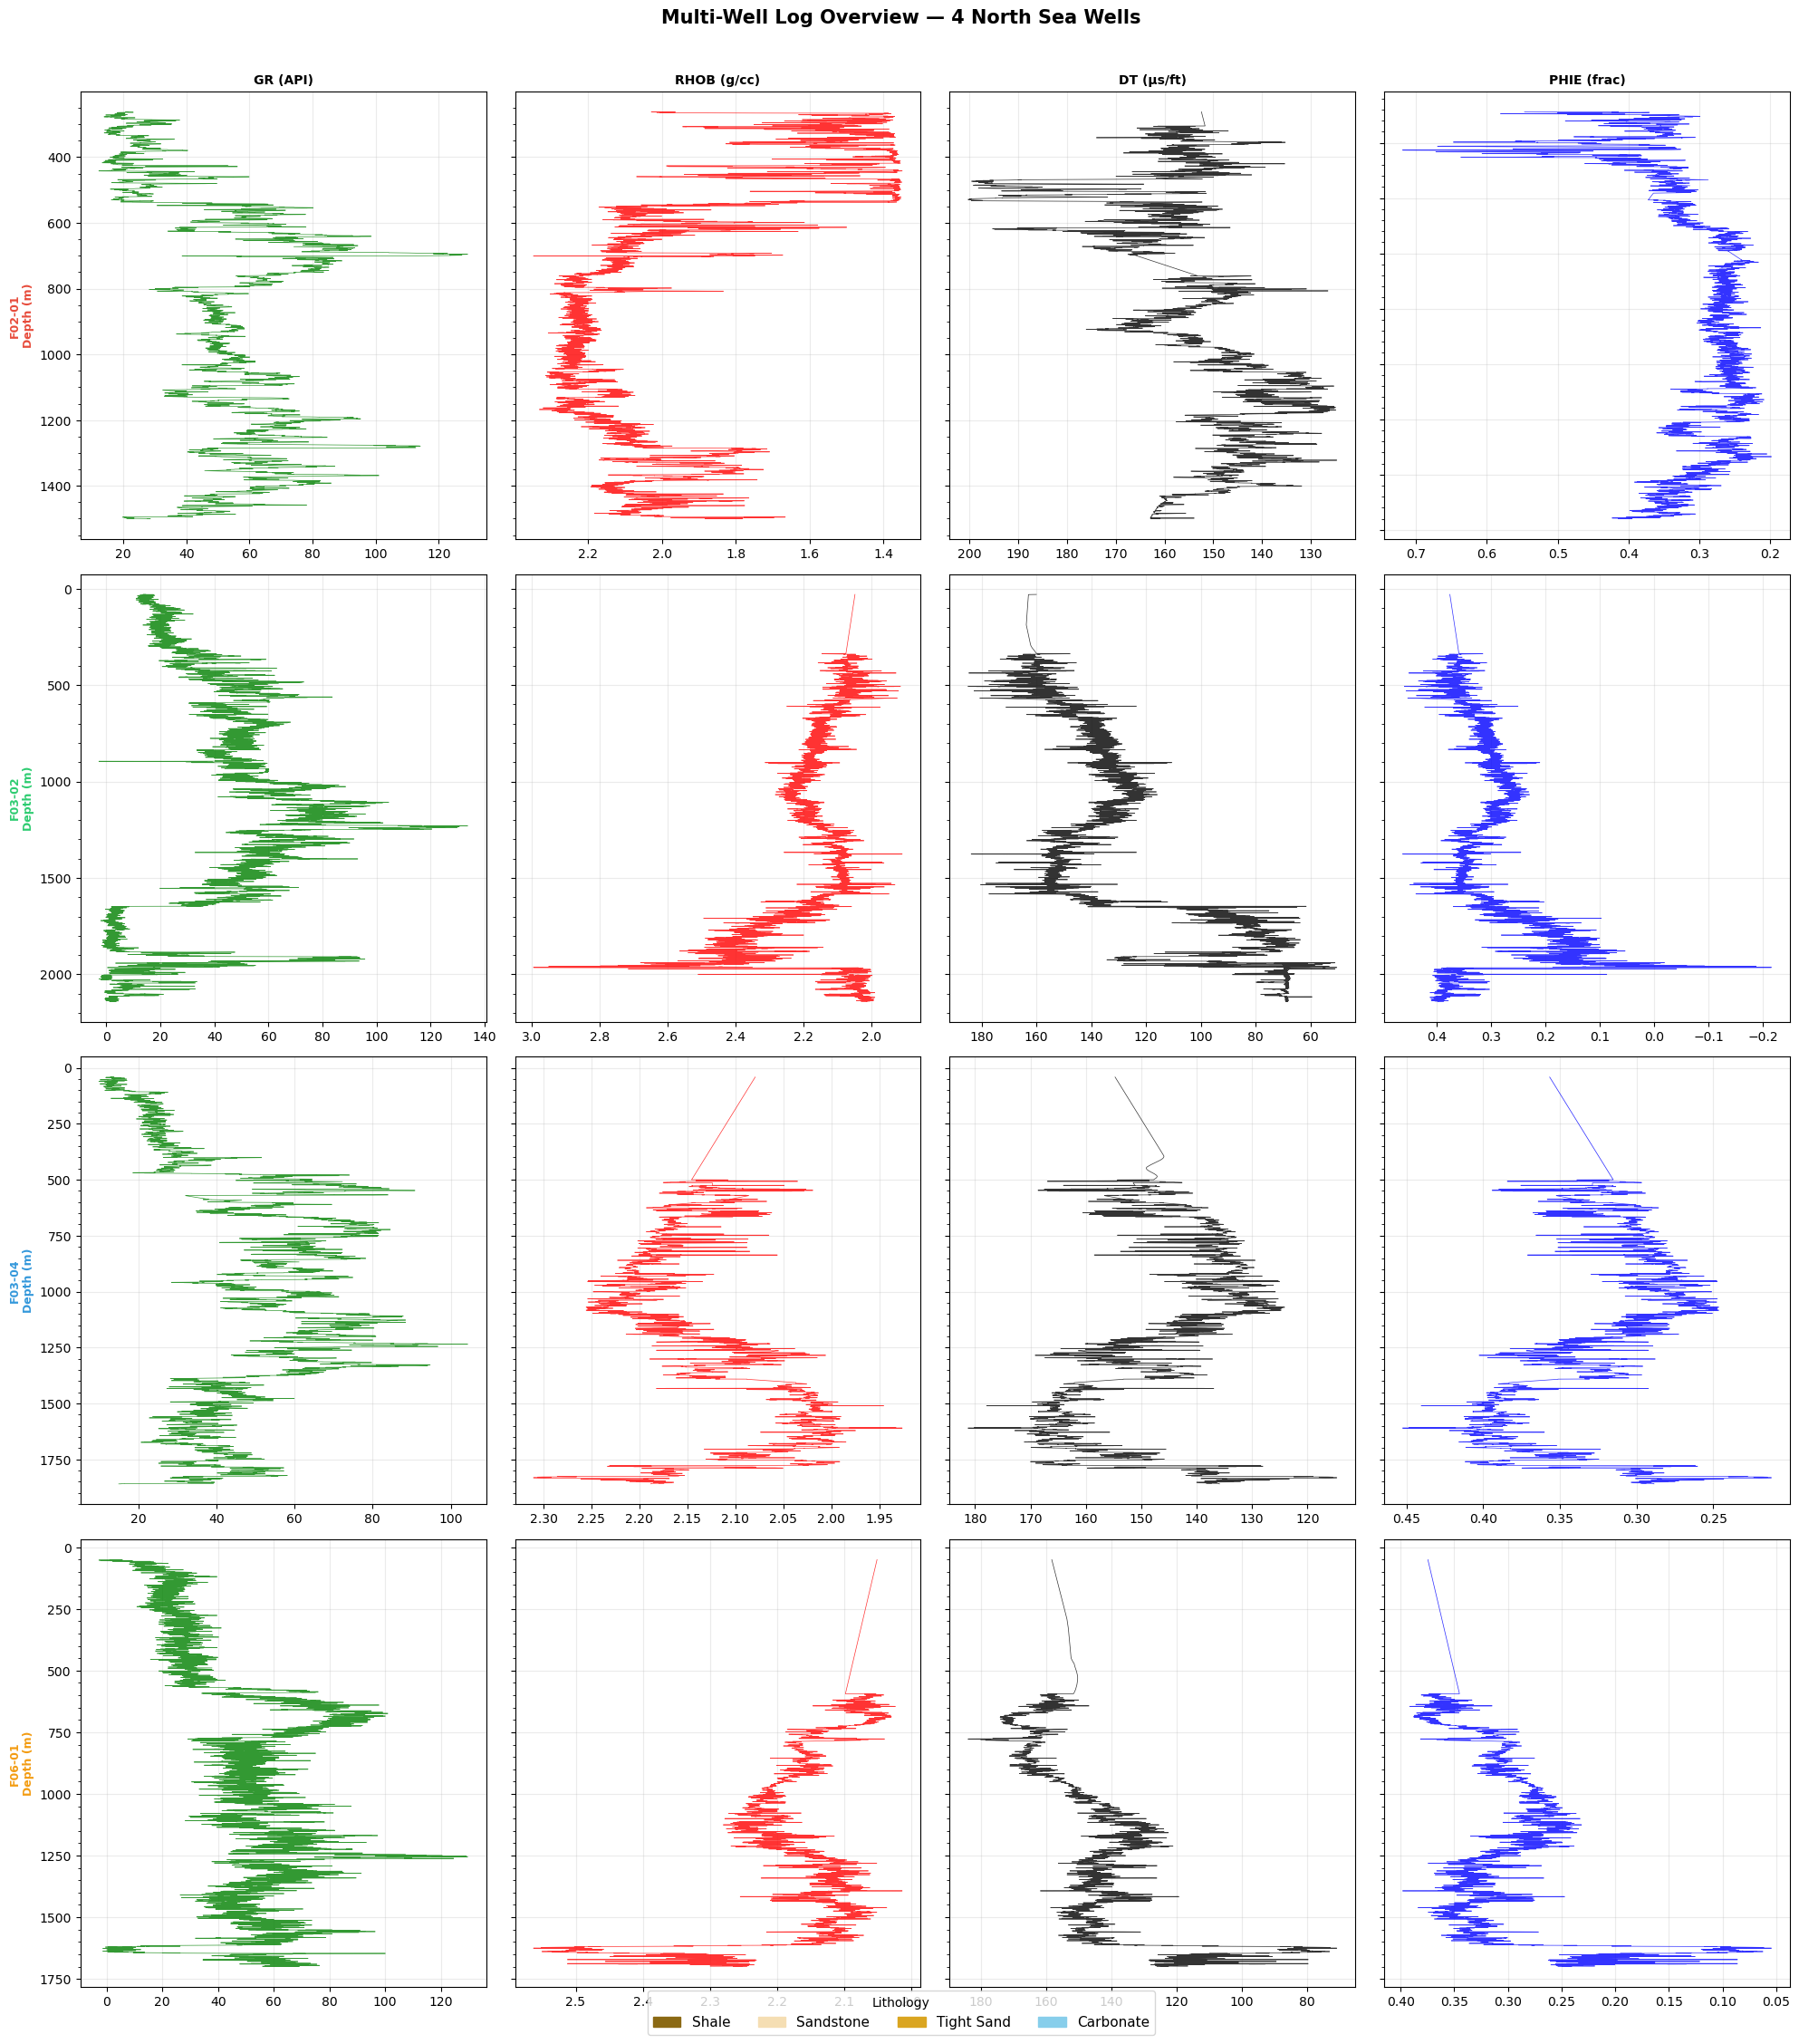

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(20, 22), sharey=False)
fig.suptitle('Multi-Well Log Overview — 4 North Sea Wells',
             fontsize=15, fontweight='bold', y=1.01)

log_cfg = [
    ('GR',      'GR (API)',     'green',  False),
    ('RHOB',    'RHOB (g/cc)',  'red',    True ),
    ('DT_CORR', 'DT (µs/ft)',   'black',  True ),
    ('PHIE',    'PHIE (frac)',  'blue',   True ),
]

for row_i, (wname, df) in enumerate(well_dfs.items()):
    pdf   = df[FEATURES + ['LITH']].dropna(subset=['GR','RHOB','LITH'])
    depth = pdf.index.values

    for col_i, (feat, xlabel, color, inv) in enumerate(log_cfg):
        ax  = axes[row_i][col_i]
        sub = pdf[feat].dropna()
        ax.plot(sub, sub.index, color=color, lw=0.5, alpha=0.8)
        if inv:
            ax.invert_xaxis()
        ax.invert_yaxis()
        ax.grid(True, alpha=0.25)
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        if row_i == 0:
            ax.set_title(xlabel, fontweight='bold', fontsize=10)
        if col_i == 0:
            ax.set_ylabel(f'{wname}\nDepth (m)', fontsize=9, fontweight='bold',
                          color=WELL_COLORS[wname])
        else:
            ax.set_yticklabels([])

legend_patches = [mpatches.Patch(color=c, label=n)
                  for n, c in LITH_COLORS.items()
                  if n in LITH_NAMES.values()]
lp = [mpatches.Patch(color=LITH_COLORS[k], label=LITH_NAMES[k])
      for k in LITH_NAMES]
fig.legend(handles=lp, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.01), fontsize=11, title='Lithology')
plt.tight_layout()
plt.show()

---
## Step 5: Cross-Well Petrophysical Cross-Plots

Check that the labelling is consistent across all 4 wells before training.

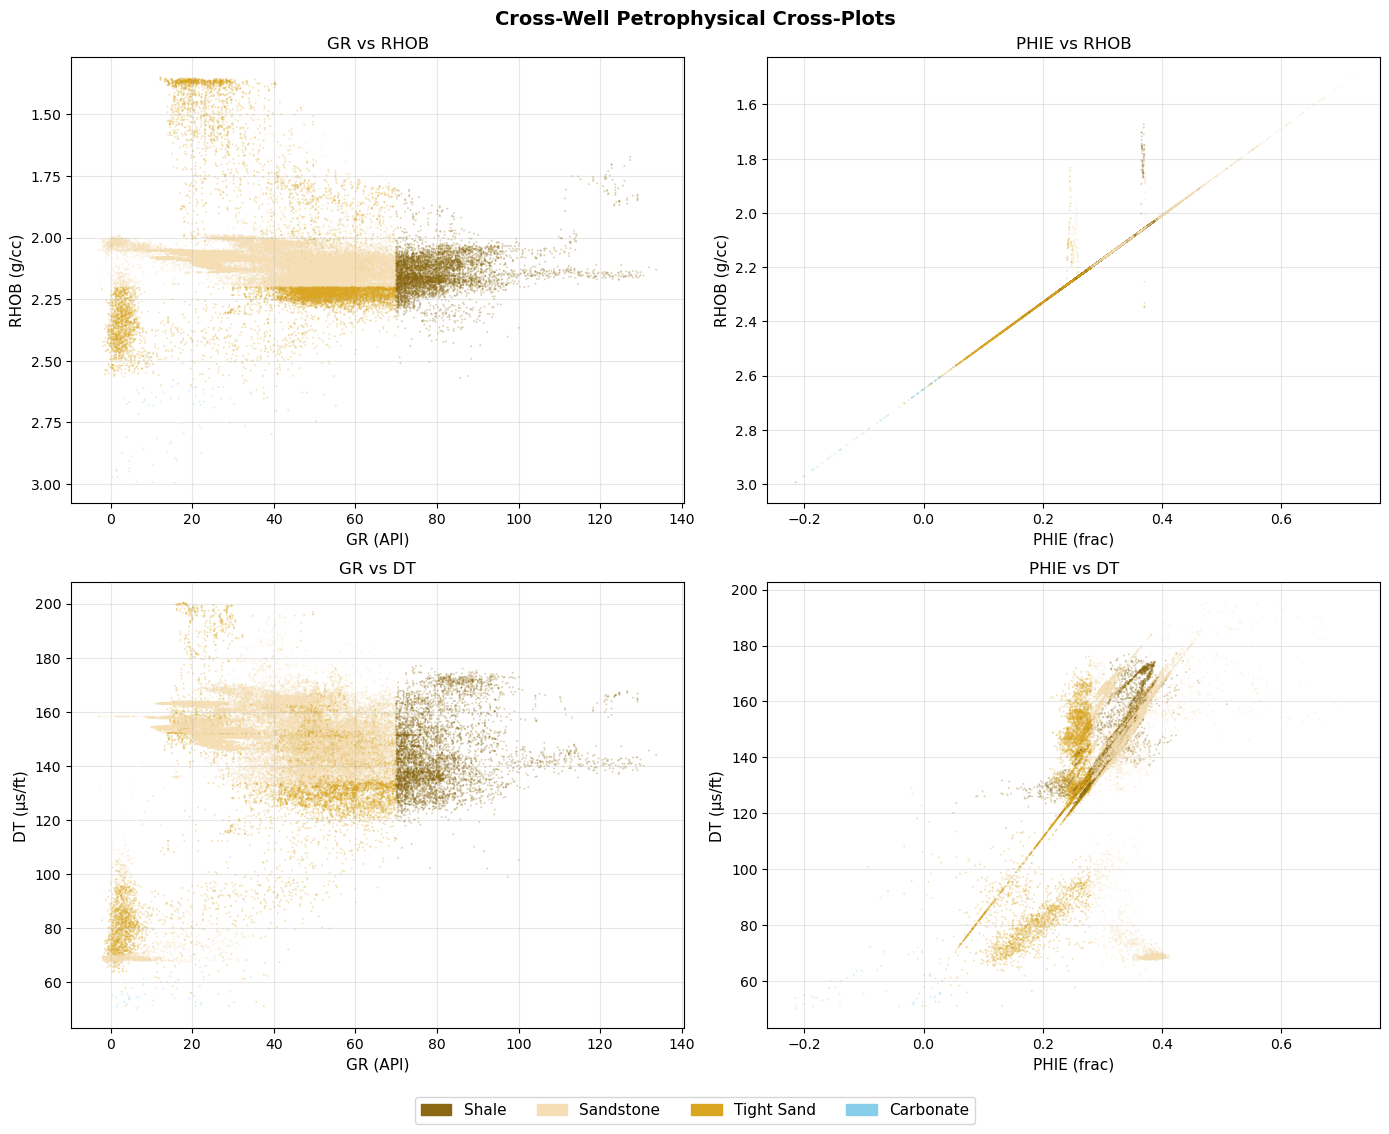

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Cross-Well Petrophysical Cross-Plots', fontsize=14, fontweight='bold')

pairs = [
    ('GR',   'RHOB',    'GR (API)',      'RHOB (g/cc)',   True),
    ('PHIE', 'RHOB',    'PHIE (frac)',   'RHOB (g/cc)',   True),
    ('GR',   'DT_CORR', 'GR (API)',      'DT (µs/ft)',    False),
    ('PHIE', 'DT_CORR', 'PHIE (frac)',   'DT (µs/ft)',    False),
]

for ax, (x, y_feat, xl, yl, inv_y) in zip(axes.flatten(), pairs):
    for wname, df in well_dfs.items():
        sub = df[[x, y_feat, 'LITH']].dropna()
        pt_colors = [LITH_COLORS[int(l)] for l in sub['LITH']]
        ax.scatter(sub[x], sub[y_feat], c=pt_colors,
                   s=2, alpha=0.3, edgecolors='none')
    ax.set_xlabel(xl, fontsize=11)
    ax.set_ylabel(yl, fontsize=11)
    ax.set_title(f'{xl.split(" ")[0]} vs {yl.split(" ")[0]}')
    if inv_y:
        ax.invert_yaxis()
    ax.grid(True, alpha=0.3)

lp = [mpatches.Patch(color=LITH_COLORS[k], label=LITH_NAMES[k]) for k in LITH_NAMES]
fig.legend(handles=lp, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.04), fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 6: Build Training & Blind-Test Datasets

**Train** on F02-01, F03-02, F03-04 → **Blind test** on F06-01

In [11]:
TRAIN_WELLS = ['F02-01', 'F03-02', 'F03-04']
TEST_WELL   = 'F06-01'

# Combine training wells
train_parts = []
for wname in TRAIN_WELLS:
    sub = well_dfs[wname][FEATURES + ['LITH','WELL']].dropna(subset=FEATURES+['LITH'])
    train_parts.append(sub)
train_df = pd.concat(train_parts)

# Blind test well
test_df = well_dfs[TEST_WELL][FEATURES + ['LITH','WELL']].dropna(subset=FEATURES+['LITH'])

X_train = train_df[FEATURES].values
y_train = train_df['LITH'].values.astype(int)

X_test  = test_df[FEATURES].values
y_test  = test_df['LITH'].values.astype(int)

# Feature scaling for KNN (not needed for RF)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set   : {len(train_df):,} samples from {TRAIN_WELLS}')
print(f'Blind test set : {len(test_df):,} samples from {TEST_WELL}')
print()
print('Class distribution in TRAINING set:')
for lid in sorted(np.unique(y_train)):
    cnt = (y_train == lid).sum()
    print(f'  {LITH_NAMES[lid]:<12}: {cnt:>6,} ({cnt/len(y_train)*100:.1f}%)')
print('\nClass distribution in TEST set (F06-01):')
present_test_labels = sorted(np.unique(y_test))
for lid in present_test_labels:
    cnt = (y_test == lid).sum()
    print(f'  {LITH_NAMES[lid]:<12}: {cnt:>6,} ({cnt/len(y_test)*100:.1f}%)')

Training set   : 29,978 samples from ['F02-01', 'F03-02', 'F03-04']
Blind test set : 10,826 samples from F06-01

Class distribution in TRAINING set:
  Shale       :  4,034 (13.5%)
  Sandstone   : 20,025 (66.8%)
  Tight Sand  :  5,851 (19.5%)
  Carbonate   :     68 (0.2%)

Class distribution in TEST set (F06-01):
  Shale       :  1,480 (13.7%)
  Sandstone   :  7,578 (70.0%)
  Tight Sand  :  1,768 (16.3%)


---
## Step 7: Random Forest — What Makes It Different?

Random Forest builds **hundreds of Decision Trees**, each trained on:
- A **random bootstrap sample** of the training data
- A **random subset of features** at each split

The final prediction is a **majority vote** across all trees — this reduces overfitting  
and gives much more robust predictions than a single Decision Tree or KNN.

```
Training Data
     │
     ├── Bootstrap 1 → Tree 1 → Prediction A
     ├── Bootstrap 2 → Tree 2 → Prediction B   → Majority Vote → Final Label
     ├── Bootstrap 3 → Tree 3 → Prediction A
     └── ... (100 trees)
```

---
## Step 8: Tune Random Forest — n_estimators & max_depth

Tuning Random Forest...


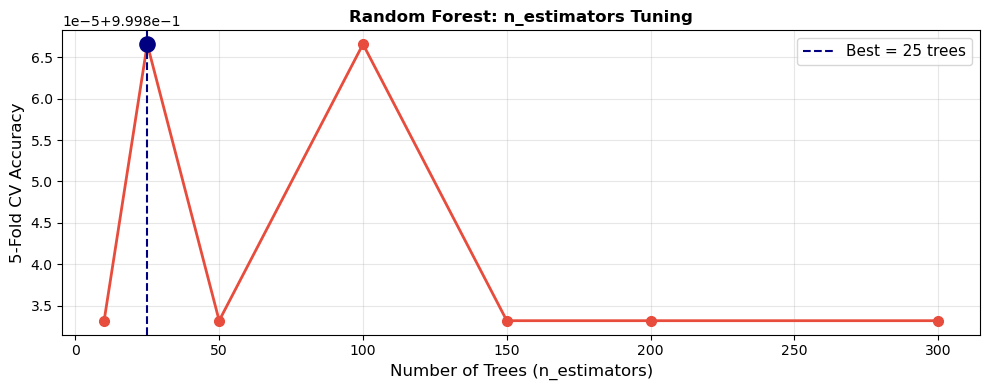


✅ Best n_estimators = 25  |  CV = 0.9999


In [13]:
print('Tuning Random Forest...')

n_trees_range = [10, 25, 50, 100, 150, 200, 300]
rf_cv_scores  = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n, max_depth=None,
                                 random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy')
    rf_cv_scores.append(scores.mean())
    print(f'  n_estimators={n:<4}  CV={scores.mean():.4f}', end='\r')

best_n = n_trees_range[np.argmax(rf_cv_scores)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_trees_range, rf_cv_scores, 'o-', color='#E74C3C', lw=2, ms=7)
ax.axvline(best_n, color='navy', lw=1.5, ls='--', label=f'Best = {best_n} trees')
ax.scatter([best_n], [max(rf_cv_scores)], color='navy', zorder=5, s=120)
ax.set_xlabel('Number of Trees (n_estimators)', fontsize=12)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('Random Forest: n_estimators Tuning', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n✅ Best n_estimators = {best_n}  |  CV = {max(rf_cv_scores):.4f}')

---
## Step 9: Tune KNN — Optimal K

Tuning KNN...


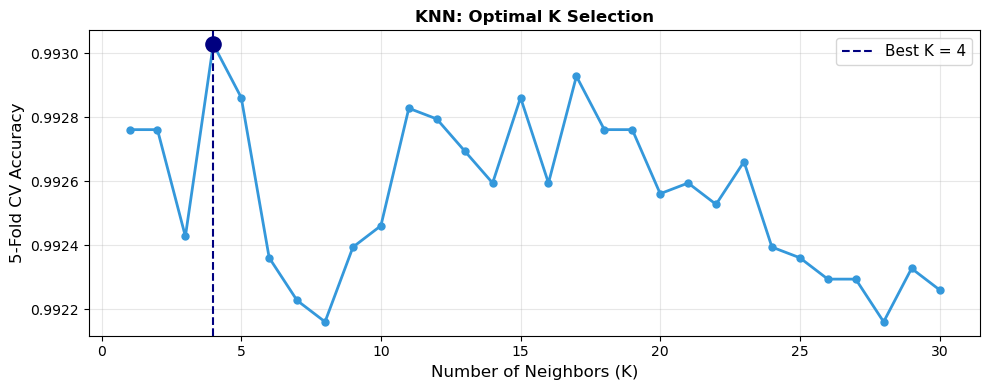


✅ Optimal K = 4  |  CV = 0.9930


In [15]:
print('Tuning KNN...')

k_range    = range(1, 31)
knn_cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    scores = cross_val_score(knn, X_train_sc, y_train, cv=skf, scoring='accuracy')
    knn_cv_scores.append(scores.mean())
    print(f'  K={k:2d}  CV={scores.mean():.4f}', end='\r')

optimal_k = list(k_range)[np.argmax(knn_cv_scores)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_range, knn_cv_scores, 'o-', color='#3498DB', lw=2, ms=5)
ax.axvline(optimal_k, color='navy', lw=1.5, ls='--', label=f'Best K = {optimal_k}')
ax.scatter([optimal_k], [max(knn_cv_scores)], color='navy', zorder=5, s=120)
ax.set_xlabel('Number of Neighbors (K)', fontsize=12)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('KNN: Optimal K Selection', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n✅ Optimal K = {optimal_k}  |  CV = {max(knn_cv_scores):.4f}')

---
## Step 10: Train Both Final Models

In [17]:
# ── Random Forest ─────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators = best_n,
    max_features = 'sqrt',       # classic RF setting
    min_samples_leaf = 2,
    random_state = 42,
    n_jobs       = -1
)
rf.fit(X_train, y_train)
y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)

# ── KNN ───────────────────────────────────────────────────
knn = KNeighborsClassifier(
    n_neighbors = optimal_k,
    metric      = 'euclidean',
    weights     = 'distance'
)
knn.fit(X_train_sc, y_train)
y_pred_knn  = knn.predict(X_test_sc)
y_proba_knn = knn.predict_proba(X_test_sc)

# ── Accuracy ──────────────────────────────────────────────
acc_rf  = accuracy_score(y_test, y_pred_rf)
acc_knn = accuracy_score(y_test, y_pred_knn)

present_labels = sorted(np.unique(np.concatenate([y_test, y_pred_rf, y_pred_knn])))
present_names  = [LITH_NAMES[l] for l in present_labels]

print('═'*56)
print(f'  BLIND WELL TEST — {TEST_WELL}')
print('═'*56)
print(f'  Random Forest  Accuracy : {acc_rf*100:.2f}%  (n={best_n} trees)')
print(f'  KNN            Accuracy : {acc_knn*100:.2f}%  (K={optimal_k})')
print('═'*56)
print()
print('── Random Forest Classification Report ────────────')
print(classification_report(y_test, y_pred_rf,
      labels=present_labels, target_names=present_names))
print('── KNN Classification Report ───────────────────────')
print(classification_report(y_test, y_pred_knn,
      labels=present_labels, target_names=present_names))

════════════════════════════════════════════════════════
  BLIND WELL TEST — F06-01
════════════════════════════════════════════════════════
  Random Forest  Accuracy : 100.00%  (n=25 trees)
  KNN            Accuracy : 98.45%  (K=4)
════════════════════════════════════════════════════════

── Random Forest Classification Report ────────────
              precision    recall  f1-score   support

       Shale       1.00      1.00      1.00      1480
   Sandstone       1.00      1.00      1.00      7578
  Tight Sand       1.00      1.00      1.00      1768

    accuracy                           1.00     10826
   macro avg       1.00      1.00      1.00     10826
weighted avg       1.00      1.00      1.00     10826

── KNN Classification Report ───────────────────────
              precision    recall  f1-score   support

       Shale       0.99      0.94      0.96      1480
   Sandstone       0.99      0.99      0.99      7578
  Tight Sand       0.96      0.98      0.97      1768

    a

---
## Step 11: Confusion Matrices — Side by Side

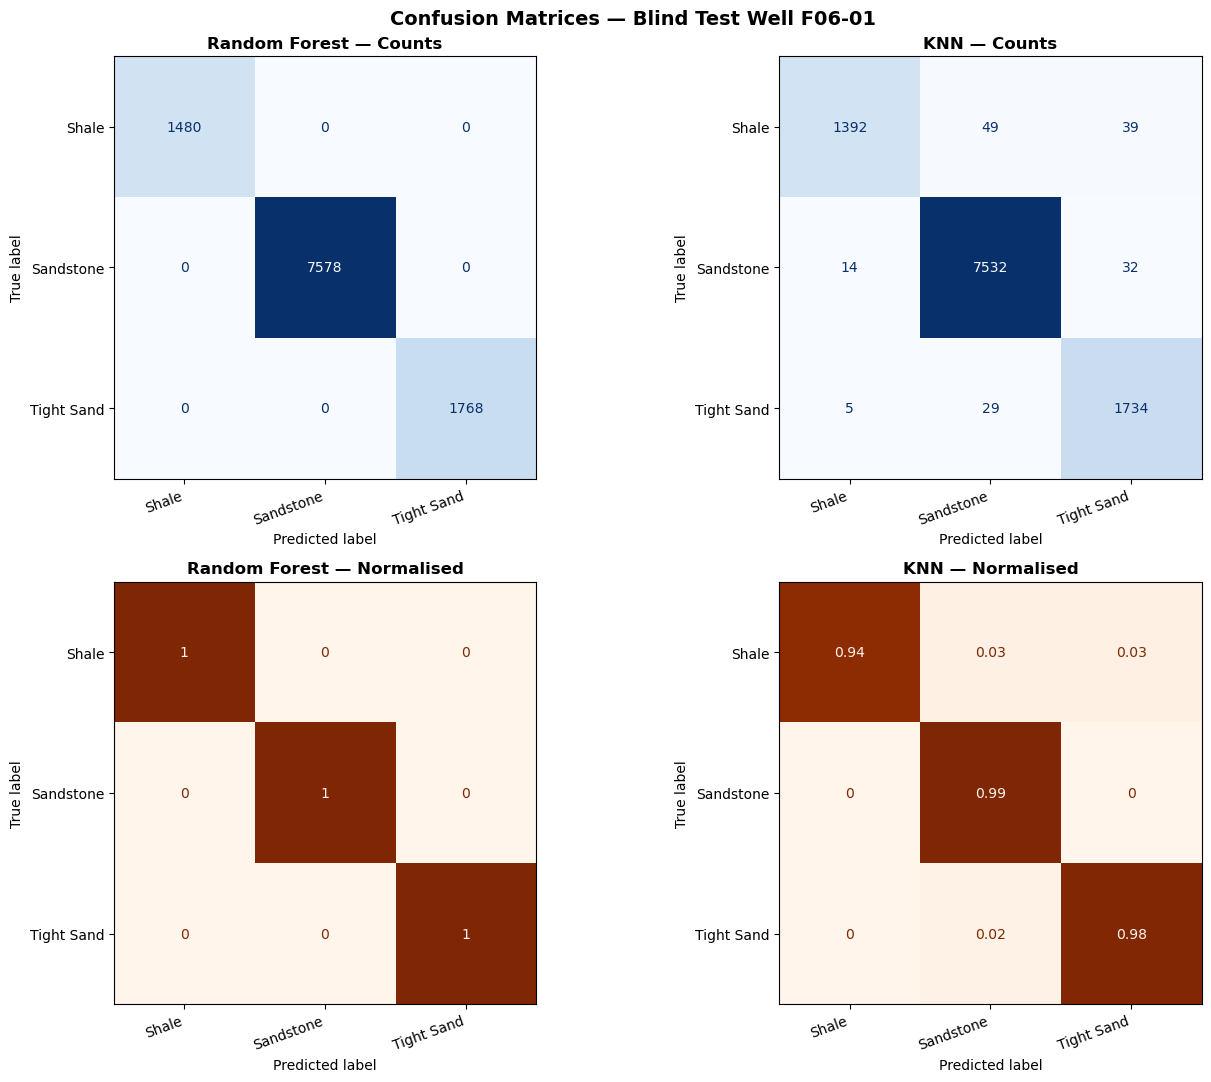

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f'Confusion Matrices — Blind Test Well {TEST_WELL}',
             fontsize=14, fontweight='bold')

for col, (model_name, y_pred) in enumerate([
    ('Random Forest', y_pred_rf),
    ('KNN', y_pred_knn)
]):
    cm      = confusion_matrix(y_test, y_pred, labels=present_labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    ConfusionMatrixDisplay(cm, display_labels=present_names).plot(
        ax=axes[0][col], cmap='Blues', colorbar=False)
    axes[0][col].set_title(f'{model_name} — Counts', fontweight='bold')
    axes[0][col].set_xticklabels(present_names, rotation=20, ha='right')

    ConfusionMatrixDisplay(cm_norm.round(2), display_labels=present_names).plot(
        ax=axes[1][col], cmap='Oranges', colorbar=False)
    axes[1][col].set_title(f'{model_name} — Normalised', fontweight='bold')
    axes[1][col].set_xticklabels(present_names, rotation=20, ha='right')

plt.tight_layout()
plt.show()

---
## Step 12: Feature Importance Comparison

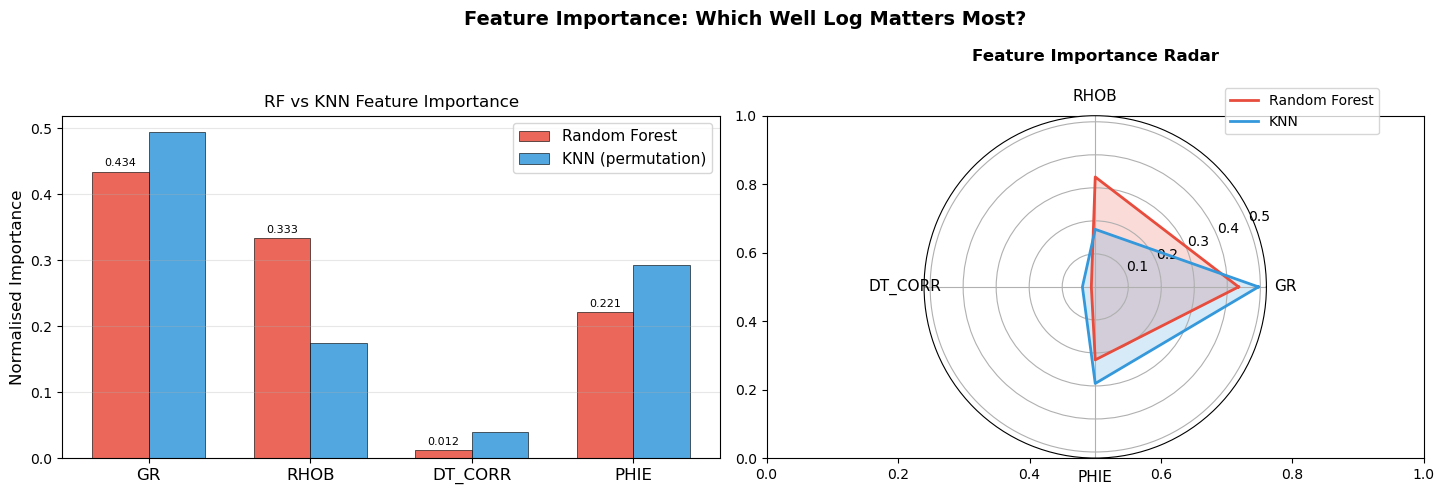

Feature importance (RF):
  GR        : 0.4341  █████████████████
  RHOB      : 0.3329  █████████████
  PHIE      : 0.2211  ████████
  DT_CORR   : 0.0118  


In [21]:
# RF native importance
rf_imp = rf.feature_importances_

# KNN permutation importance
perm   = permutation_importance(knn, X_test_sc, y_test, n_repeats=15, random_state=42)
knn_imp = perm.importances_mean
knn_imp = np.clip(knn_imp, 0, None)  # clip negatives to 0

# Normalise KNN for fair comparison
knn_imp_norm = knn_imp / knn_imp.sum() if knn_imp.sum() > 0 else knn_imp

x       = np.arange(len(FEATURES))
width   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Feature Importance: Which Well Log Matters Most?',
             fontsize=14, fontweight='bold')

# Side-by-side bar
bars1 = axes[0].bar(x - width/2, rf_imp,       width, label='Random Forest',
                    color='#E74C3C', alpha=0.85, edgecolor='black', lw=0.5)
bars2 = axes[0].bar(x + width/2, knn_imp_norm, width, label='KNN (permutation)',
                    color='#3498DB', alpha=0.85, edgecolor='black', lw=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(FEATURES, fontsize=12)
axes[0].set_ylabel('Normalised Importance', fontsize=12)
axes[0].set_title('RF vs KNN Feature Importance')
axes[0].legend(fontsize=11)
axes[0].grid(True, axis='y', alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Radar / Spider chart
angles = np.linspace(0, 2*np.pi, len(FEATURES), endpoint=False).tolist()
angles += angles[:1]
rf_vals  = rf_imp.tolist()  + rf_imp[:1].tolist()
knn_vals = knn_imp_norm.tolist() + knn_imp_norm[:1].tolist()

ax_r = axes[1]
ax_r = fig.add_subplot(122, polar=True)
ax_r.plot(angles, rf_vals,  color='#E74C3C', lw=2, label='Random Forest')
ax_r.fill(angles, rf_vals,  color='#E74C3C', alpha=0.2)
ax_r.plot(angles, knn_vals, color='#3498DB', lw=2, label='KNN')
ax_r.fill(angles, knn_vals, color='#3498DB', alpha=0.2)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(FEATURES, fontsize=11)
ax_r.set_title('Feature Importance Radar', fontweight='bold', pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

print('Feature importance (RF):')
for f, v in sorted(zip(FEATURES, rf_imp), key=lambda x: -x[1]):
    print(f'  {f:<10}: {v:.4f}  {"█"*int(v*40)}')

---
## Step 13: Prediction Confidence — Where Do Models Disagree?

Both models agree     : 10,658 samples (98.4%)
Models disagree       :   168 samples (1.6%)
RF correct where disagree  : 100.0%
KNN correct where disagree : 0.0%


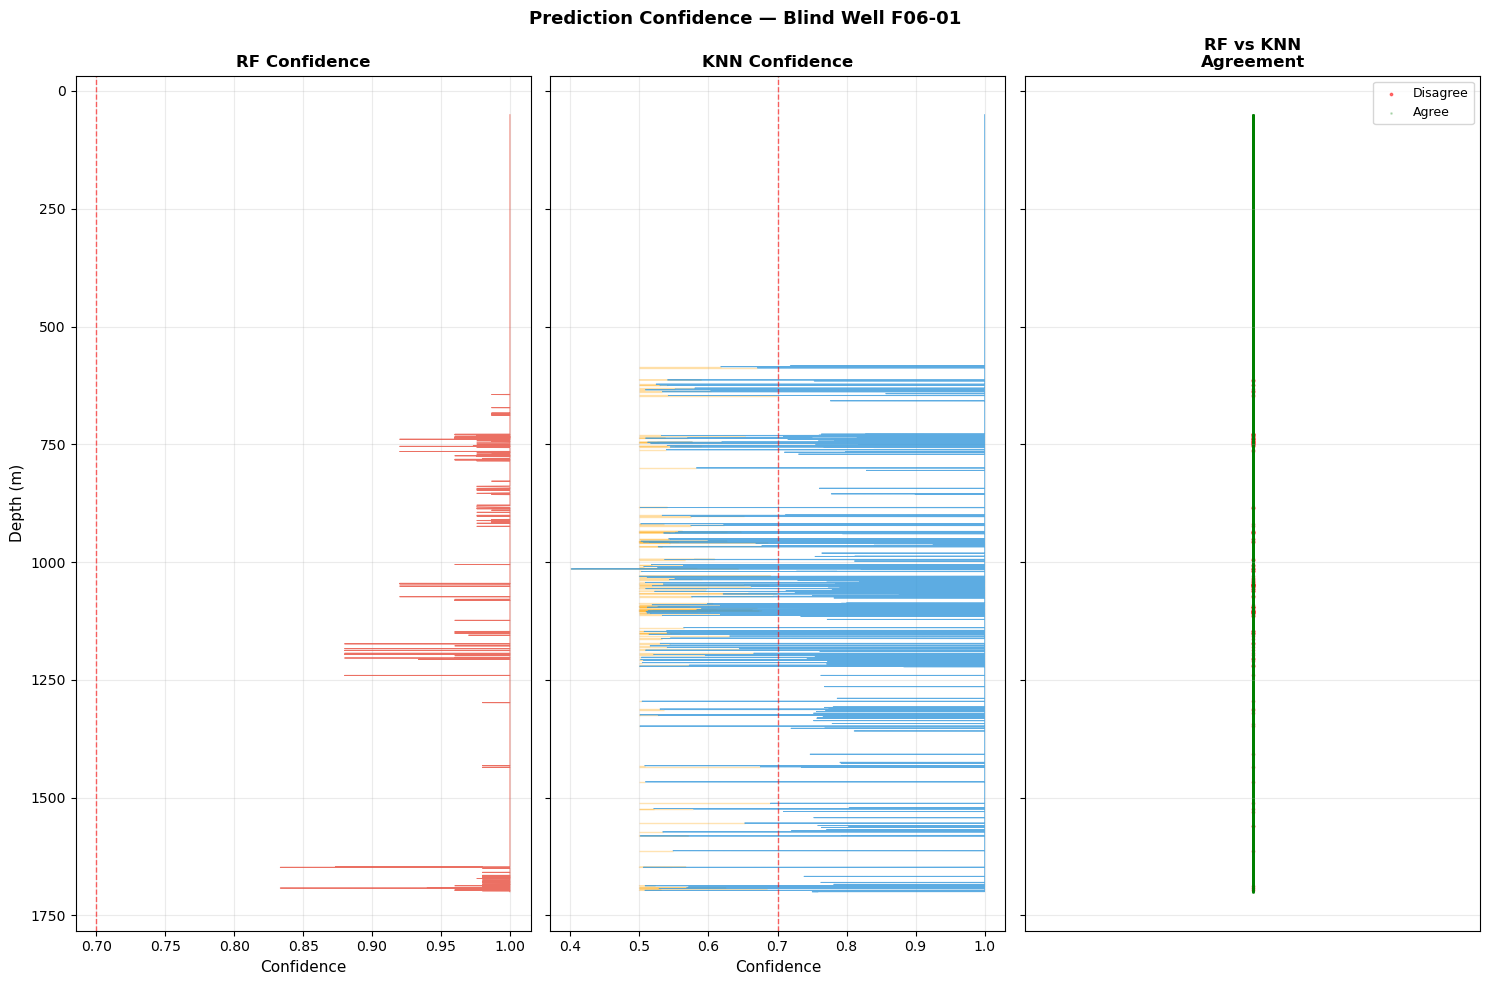

In [23]:
conf_rf  = y_proba_rf.max(axis=1)   # max class probability
conf_knn = y_proba_knn.max(axis=1)
depth_test = test_df.index.values

# Agreement mask
agree    = (y_pred_rf == y_pred_knn)
disagree = ~agree

print(f'Both models agree     : {agree.sum():>5,} samples ({agree.mean()*100:.1f}%)')
print(f'Models disagree       : {disagree.sum():>5,} samples ({disagree.mean()*100:.1f}%)')
print(f'RF correct where disagree  : '
      f'{(y_pred_rf[disagree] == y_test[disagree]).mean()*100:.1f}%')
print(f'KNN correct where disagree : '
      f'{(y_pred_knn[disagree] == y_test[disagree]).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(15, 10), sharey=True)
fig.suptitle(f'Prediction Confidence — Blind Well {TEST_WELL}',
             fontsize=13, fontweight='bold')

# RF confidence
axes[0].plot(conf_rf, depth_test, color='#E74C3C', lw=0.6, alpha=0.8)
axes[0].fill_betweenx(depth_test, conf_rf, 0.5,
                       where=conf_rf < 0.7, color='orange', alpha=0.3)
axes[0].axvline(0.7, color='red', lw=1, ls='--', alpha=0.6)
axes[0].set_xlabel('Confidence', fontsize=11)
axes[0].set_title('RF Confidence', fontweight='bold')
axes[0].set_ylabel('Depth (m)', fontsize=11)
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.25)

# KNN confidence
axes[1].plot(conf_knn, depth_test, color='#3498DB', lw=0.6, alpha=0.8)
axes[1].fill_betweenx(depth_test, conf_knn, 0.5,
                       where=conf_knn < 0.7, color='orange', alpha=0.3)
axes[1].axvline(0.7, color='red', lw=1, ls='--', alpha=0.6)
axes[1].set_xlabel('Confidence', fontsize=11)
axes[1].set_title('KNN Confidence', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.25)

# Disagreement track
axes[2].scatter(np.ones(disagree.sum()) * 0.5, depth_test[disagree],
                c='red', s=3, alpha=0.5, label='Disagree')
axes[2].scatter(np.ones(agree.sum()) * 0.5, depth_test[agree],
                c='green', s=1, alpha=0.2, label='Agree')
axes[2].set_xticks([])
axes[2].set_title('RF vs KNN\nAgreement', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].invert_yaxis()
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

---
## Step 14: Full Well Log Track — True vs RF vs KNN

The definitive geoscience visualisation — GR + RHOB logs alongside  
rule-based labels, RF predictions, and KNN predictions.

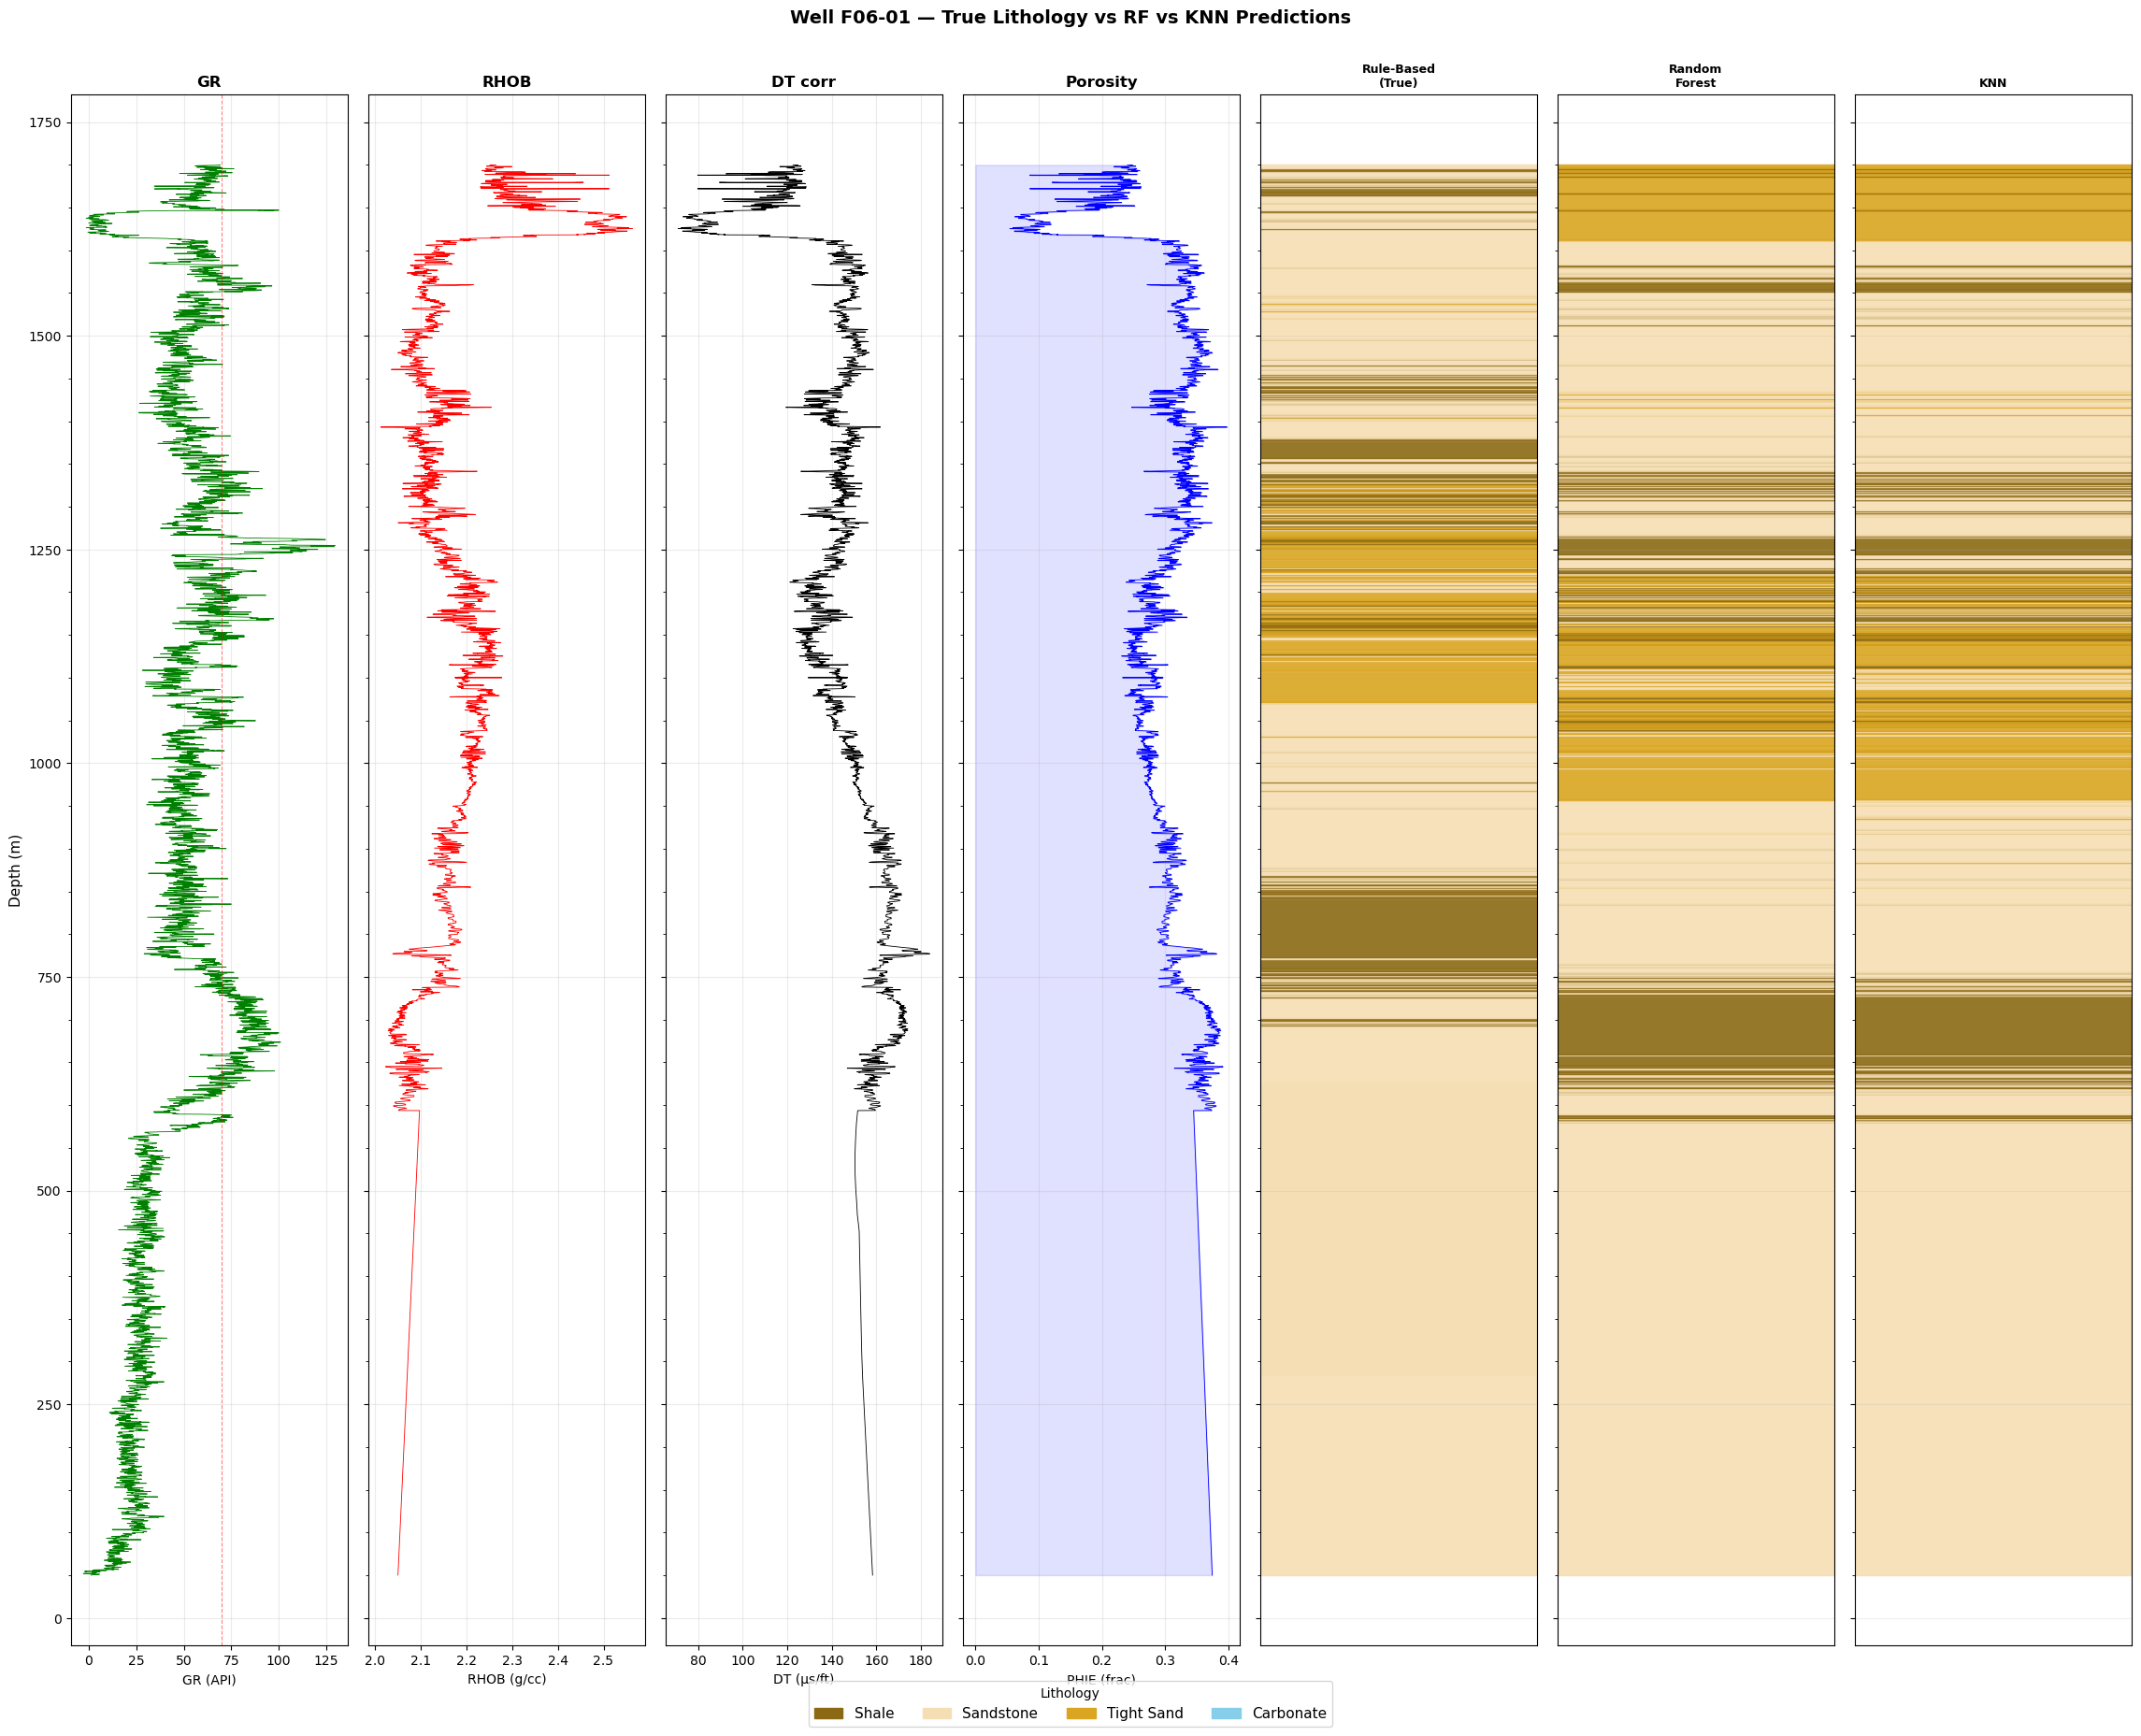

In [27]:
def fill_lith_track(ax, depth_arr, lith_arr, color_map, title):
    """Fill a lithology track with colour bands."""
    lith_arr = np.array(lith_arr, dtype=float)
    prev, start = lith_arr[0], depth_arr[0]
    for i in range(1, len(depth_arr)):
        if lith_arr[i] != prev or i == len(depth_arr)-1:
            if not np.isnan(prev):
                ax.fill_betweenx([start, depth_arr[i]], 0, 1,
                                 color=color_map.get(int(prev), '#CCC'), alpha=0.9)
            start, prev = depth_arr[i], lith_arr[i]
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.2)

# Predict across full test well
full_test  = well_dfs[TEST_WELL][FEATURES].dropna()
X_full     = scaler.transform(full_test.values)
rf_full    = rf.predict(full_test.values)
knn_full   = knn.predict(X_full)
depth_full = full_test.index.values
true_full  = well_dfs[TEST_WELL].loc[full_test.index, 'LITH'].values

pf  = well_dfs[TEST_WELL][FEATURES + ['LITH']].dropna(subset=['GR', 'RHOB'])
dep = pf.index.values

# ── Build all 7 panels in one go with sharey=True ────────
fig, axes = plt.subplots(1, 7, figsize=(23, 18), sharey=True)
fig.suptitle(f'Well {TEST_WELL} — True Lithology vs RF vs KNN Predictions',
             fontsize=14, fontweight='bold', y=1.005)

# GR
axes[0].plot(pf['GR'], dep, color='green', lw=0.6)
axes[0].axvline(70, color='red', lw=0.8, ls='--', alpha=0.5)
axes[0].set_xlabel('GR (API)', fontsize=10)
axes[0].set_ylabel('Depth (m)', fontsize=11)
axes[0].set_title('GR', fontweight='bold')
axes[0].grid(True, alpha=0.25)

# RHOB
axes[1].plot(pf['RHOB'], dep, color='red', lw=0.6)
axes[1].set_xlabel('RHOB (g/cc)', fontsize=10)
axes[1].set_title('RHOB', fontweight='bold')
axes[1].grid(True, alpha=0.25)

# DT
axes[2].plot(pf['DT_CORR'], dep, color='black', lw=0.6)
axes[2].set_xlabel('DT (µs/ft)', fontsize=10)
axes[2].set_title('DT corr', fontweight='bold')
axes[2].grid(True, alpha=0.25)

# PHIE
axes[3].plot(pf['PHIE'], dep, color='blue', lw=0.6)
axes[3].fill_betweenx(dep, pf['PHIE'], 0, color='blue', alpha=0.12)
axes[3].set_xlabel('PHIE (frac)', fontsize=10)
axes[3].set_title('Porosity', fontweight='bold')
axes[3].grid(True, alpha=0.25)

# True lithology
fill_lith_track(axes[4], depth_full, true_full, LITH_COLORS, 'Rule-Based\n(True)')

# RF predictions
fill_lith_track(axes[5], depth_full, rf_full,   LITH_COLORS, 'Random\nForest')

# KNN predictions
fill_lith_track(axes[6], depth_full, knn_full,  LITH_COLORS, 'KNN')

# All axes share Y — just invert once
axes[0].invert_yaxis()
for ax in axes:
    ax.yaxis.set_minor_locator(AutoMinorLocator())

lp = [mpatches.Patch(color=LITH_COLORS[k], label=LITH_NAMES[k]) for k in LITH_NAMES]
fig.legend(handles=lp, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), fontsize=11, title='Lithology')
plt.tight_layout()
plt.show()

---
## Step 15: Per-Well Cross-Validation (All 4 Wells)

Leave-One-Well-Out (LOWO) cross-validation — the most rigorous multi-well test.

In [31]:
all_wells = list(WELL_FILES.keys())
lowo_results = []

for test_w in all_wells:
    train_ws = [w for w in all_wells if w != test_w]

    # Build train set
    tr_parts = [well_dfs[w][FEATURES+['LITH']].dropna() for w in train_ws]
    tr_df = pd.concat(tr_parts)
    Xtr = tr_df[FEATURES].values
    ytr = tr_df['LITH'].values.astype(int)

    # Build test set
    te_df = well_dfs[test_w][FEATURES+['LITH']].dropna()
    Xte = te_df[FEATURES].values
    yte = te_df['LITH'].values.astype(int)

    sc_lowo = StandardScaler().fit(Xtr)

    # RF
    rf_l = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)
    rf_l.fit(Xtr, ytr)
    acc_rf_l  = accuracy_score(yte, rf_l.predict(Xte))
    f1_rf_l   = f1_score(yte, rf_l.predict(Xte), average='weighted')

    # KNN
    knn_l = KNeighborsClassifier(n_neighbors=optimal_k, weights='distance')
    knn_l.fit(sc_lowo.transform(Xtr), ytr)
    acc_knn_l = accuracy_score(yte, knn_l.predict(sc_lowo.transform(Xte)))
    f1_knn_l  = f1_score(yte, knn_l.predict(sc_lowo.transform(Xte)), average='weighted')

    lowo_results.append({
        'Test Well'   : test_w,
        'Train Wells' : ', '.join(train_ws),
        'RF Acc'      : acc_rf_l,
        'KNN Acc'     : acc_knn_l,
        'RF F1'       : f1_rf_l,
        'KNN F1'      : f1_knn_l,
        'Winner'      : 'RF' if acc_rf_l >= acc_knn_l else 'KNN'
    })
    print(f'  {test_w}  →  RF={acc_rf_l*100:.1f}%  KNN={acc_knn_l*100:.1f}%  '
          f'Winner: {"RF" if acc_rf_l >= acc_knn_l else "KNN"}')

lowo_df = pd.DataFrame(lowo_results)
print()
print('LOWO Summary:')
print(lowo_df[['Test Well','RF Acc','KNN Acc','RF F1','KNN F1','Winner']].to_string(index=False))
print()
print(f'Mean RF  Accuracy : {lowo_df["RF Acc"].mean()*100:.2f}%')
print(f'Mean KNN Accuracy : {lowo_df["KNN Acc"].mean()*100:.2f}%')

  F02-01  →  RF=98.8%  KNN=94.5%  Winner: RF
  F03-02  →  RF=99.5%  KNN=96.4%  Winner: RF
  F03-04  →  RF=100.0%  KNN=99.0%  Winner: RF
  F06-01  →  RF=100.0%  KNN=98.4%  Winner: RF

LOWO Summary:
Test Well   RF Acc  KNN Acc    RF F1   KNN F1 Winner
   F02-01 0.988230 0.945450 0.988261 0.945698     RF
   F03-02 0.994989 0.964128 0.992554 0.962632     RF
   F03-04 1.000000 0.989906 1.000000 0.989893     RF
   F06-01 1.000000 0.984482 1.000000 0.984426     RF

Mean RF  Accuracy : 99.58%
Mean KNN Accuracy : 97.10%


---
## Step 16: Final Comparison Dashboard

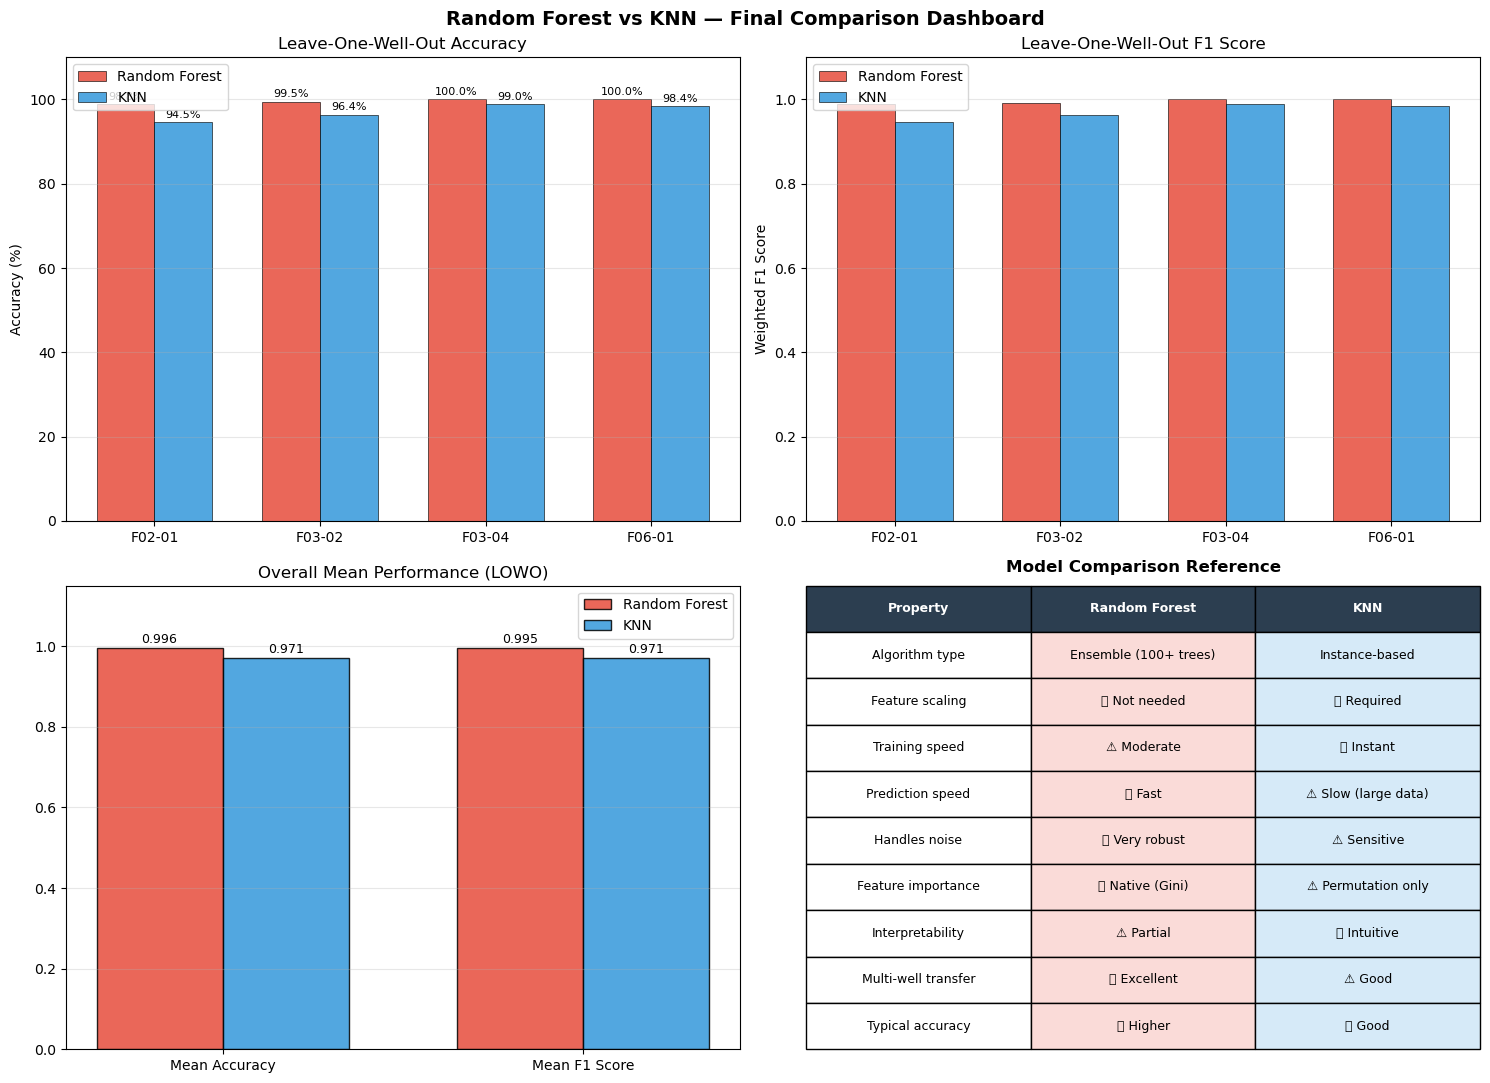

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Random Forest vs KNN — Final Comparison Dashboard',
             fontsize=14, fontweight='bold')

wells_lowo = lowo_df['Test Well'].tolist()
x_pos      = np.arange(len(wells_lowo))
w          = 0.35

# ── 1. LOWO Accuracy per well ─────────────────────────────
ax = axes[0][0]
ax.bar(x_pos - w/2, lowo_df['RF Acc']*100,  w, label='Random Forest',
       color='#E74C3C', alpha=0.85, edgecolor='black', lw=0.5)
ax.bar(x_pos + w/2, lowo_df['KNN Acc']*100, w, label='KNN',
       color='#3498DB', alpha=0.85, edgecolor='black', lw=0.5)
for i, row in lowo_df.iterrows():
    ax.text(i-w/2, row['RF Acc']*100+0.5, f'{row["RF Acc"]*100:.1f}%',
            ha='center', va='bottom', fontsize=8)
    ax.text(i+w/2, row['KNN Acc']*100+0.5, f'{row["KNN Acc"]*100:.1f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(wells_lowo)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Leave-One-Well-Out Accuracy')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 110)

# ── 2. LOWO F1 Score per well ─────────────────────────────
ax = axes[0][1]
ax.bar(x_pos - w/2, lowo_df['RF F1'],  w, label='Random Forest',
       color='#E74C3C', alpha=0.85, edgecolor='black', lw=0.5)
ax.bar(x_pos + w/2, lowo_df['KNN F1'], w, label='KNN',
       color='#3498DB', alpha=0.85, edgecolor='black', lw=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(wells_lowo)
ax.set_ylabel('Weighted F1 Score')
ax.set_title('Leave-One-Well-Out F1 Score')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

# ── 3. Mean accuracy comparison (bar) ────────────────────
ax = axes[1][0]
metrics = ['Mean Accuracy', 'Mean F1 Score']
rf_vals  = [lowo_df['RF Acc'].mean(),  lowo_df['RF F1'].mean()]
knn_vals = [lowo_df['KNN Acc'].mean(), lowo_df['KNN F1'].mean()]
xm = np.arange(2)
ax.bar(xm - w/2, rf_vals,  w, label='Random Forest', color='#E74C3C', alpha=0.85, edgecolor='black')
ax.bar(xm + w/2, knn_vals, w, label='KNN',           color='#3498DB', alpha=0.85, edgecolor='black')
for i, (rv, kv) in enumerate(zip(rf_vals, knn_vals)):
    ax.text(i-w/2, rv+0.005, f'{rv:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i+w/2, kv+0.005, f'{kv:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(xm)
ax.set_xticklabels(metrics)
ax.set_title('Overall Mean Performance (LOWO)')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# ── 4. Model properties comparison table ─────────────────
ax = axes[1][1]
ax.axis('off')
table_data = [
    ['Property',             'Random Forest',         'KNN'],
    ['Algorithm type',       'Ensemble (100+ trees)', 'Instance-based'],
    ['Feature scaling',      '❌ Not needed',          '✅ Required'],
    ['Training speed',       '⚠️ Moderate',            '✅ Instant'],
    ['Prediction speed',     '✅ Fast',                '⚠️ Slow (large data)'],
    ['Handles noise',        '✅ Very robust',         '⚠️ Sensitive'],
    ['Feature importance',   '✅ Native (Gini)',       '⚠️ Permutation only'],
    ['Interpretability',     '⚠️ Partial',             '✅ Intuitive'],
    ['Multi-well transfer',  '✅ Excellent',           '⚠️ Good'],
    ['Typical accuracy',     '🏆 Higher',             '✅ Good'],
]
tbl = ax.table(
    cellText  = table_data[1:],
    colLabels = table_data[0],
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
# Header styling
for j in range(3):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
# Column colouring
for i in range(1, len(table_data)):
    tbl[i, 1].set_facecolor('#FADBD8')
    tbl[i, 2].set_facecolor('#D6EAF8')
ax.set_title('Model Comparison Reference', fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

---
## Step 17: Final Verdict

In [35]:
mean_rf  = lowo_df['RF Acc'].mean()
mean_knn = lowo_df['KNN Acc'].mean()
rf_wins  = (lowo_df['RF Acc'] >= lowo_df['KNN Acc']).sum()

print('═'*62)
print('  🏆  FINAL VERDICT — 4-WELL NORTH SEA STUDY')
print('═'*62)
print(f'  Random Forest  mean LOWO accuracy : {mean_rf*100:.2f}%')
print(f'  KNN            mean LOWO accuracy : {mean_knn*100:.2f}%')
print(f'  RF wins on {rf_wins}/{len(all_wells)} wells')
print()
winner = 'Random Forest' if mean_rf >= mean_knn else 'KNN'
print(f'  🥇 Overall winner: {winner}')
print()
print('  Why Random Forest typically wins in geoscience:')
print('  • Robust to depth-related log trends across wells')
print('  • No sensitivity to feature scale differences')
print('  • Handles class imbalance better (shale-dominated sections)')
print('  • Native feature importance helps geoscientists understand')
print('    which log drives the classification')
print()
print('  When KNN can compete:')
print('  • Very clean, well-normalised logs across wells')
print('  • Dense, uniform depth sampling')
print('  • Similar depth ranges between train and test wells')
print('═'*62)

══════════════════════════════════════════════════════════════
  🏆  FINAL VERDICT — 4-WELL NORTH SEA STUDY
══════════════════════════════════════════════════════════════
  Random Forest  mean LOWO accuracy : 99.58%
  KNN            mean LOWO accuracy : 97.10%
  RF wins on 4/4 wells

  🥇 Overall winner: Random Forest

  Why Random Forest typically wins in geoscience:
  • Robust to depth-related log trends across wells
  • No sensitivity to feature scale differences
  • Handles class imbalance better (shale-dominated sections)
  • Native feature importance helps geoscientists understand
    which log drives the classification

  When KNN can compete:
  • Very clean, well-normalised logs across wells
  • Dense, uniform depth sampling
  • Similar depth ranges between train and test wells
══════════════════════════════════════════════════════════════


---
## Summary

| Step | What Was Done |
|------|---------------|
| 2 | Loaded all 4 LAS files — 4 common curves: GR, RHOB, DT_CORR, PHIE |
| 3 | Applied consistent petrophysical cut-offs across all wells |
| 4 | Multi-well log track overview (4 × 4 panel plot) |
| 5 | Cross-well cross-plots to verify labelling consistency |
| 6 | **Train on 3 wells → Blind test on F06-01** |
| 7 | Explained Random Forest ensemble concept |
| 8–9 | Tuned n_estimators (RF) and optimal K (KNN) via cross-validation |
| 10 | Trained both final models, printed classification reports |
| 11 | Side-by-side confusion matrices (counts + normalised) |
| 12 | Feature importance comparison — bar chart + radar plot |
| 13 | Prediction confidence tracks + agreement/disagreement analysis |
| 14 | **Full 7-panel well log track**: logs + True + RF + KNN |
| 15 | **Leave-One-Well-Out (LOWO)** validation across all 4 wells |
| 16 | Final comparison dashboard with model properties table |
| 17 | Final verdict with geoscience interpretation |

### Key Takeaway
**Random Forest is generally the better choice** for multi-well lithology prediction because it is robust to inter-well log variability, requires no normalisation, and provides native feature importance — all critical advantages in real field studies.  
**KNN** remains competitive when logs are well-normalised and depth ranges are similar across wells.

### Next Steps
- Add **resistivity (RT)** and **NPHI** if available — improve carbonate detection
- Integrate **core descriptions** for ground-truth labels
- Try **XGBoost** or **SVM** as additional comparison models
- Apply to seismic-derived pseudo-logs for field-wide lithology mapping